In [3]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 35.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 38.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Setup (run once)
import pandas as pd
import matplotlib.pyplot as pd_plt_module  # noqa: F401 — keep plt name clear
import matplotlib.pyplot as plt

CSV_PATH = "seattle_weather.csv"  # or: "week-5-class-activity/seattle_weather.csv"

df = pd.read_csv(CSV_PATH)
df["time"] = pd.to_datetime(df["time"])

Matplotlib is building the font cache; this may take a moment.


In [5]:
# 1 — structure and time integrity
print("Rows, columns:", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nDtypes:\n", df.dtypes)

print("\nTime range:")
print("  earliest:", df["time"].min())
print("  latest:  ", df["time"].max())

# Expected: one row per hour, no duplicate timestamps
dup_ts = df["time"].duplicated().sum()
print("\nDuplicate timestamps:", int(dup_ts))

df_sorted = df.sort_values("time").reset_index(drop=True)
deltas = df_sorted["time"].diff().dropna()
# Timedelta between consecutive rows (should be 1 hour if regular)
print("\nTime deltas between consecutive rows (value_counts):")
print(deltas.value_counts().head(10))
irregular = deltas[deltas != pd.Timedelta(hours=1)]
print("Rows after an irregular gap (excluding first row):", len(irregular))

Rows, columns: (168, 5)

Column names:
 ['time', 'temperature_2m_celsius', 'relative_humidity_2m_percent', 'precipitation_mm', 'wind_speed_10m_kmh']

Dtypes:
 time                            datetime64[us]
temperature_2m_celsius                 float64
relative_humidity_2m_percent             int64
precipitation_mm                       float64
wind_speed_10m_kmh                     float64
dtype: object

Time range:
  earliest: 2026-04-28 00:00:00
  latest:   2026-05-04 23:00:00

Duplicate timestamps: 0

Time deltas between consecutive rows (value_counts):
time
0 days 01:00:00    167
Name: count, dtype: int64
Rows after an irregular gap (excluding first row): 0


Summary statistics (full series):


count    168.000000
mean      14.347619
std        5.096822
min        5.600000
25%       10.100000
50%       13.300000
75%       17.850000
max       25.500000
Name: temperature_2m_celsius, dtype: float64

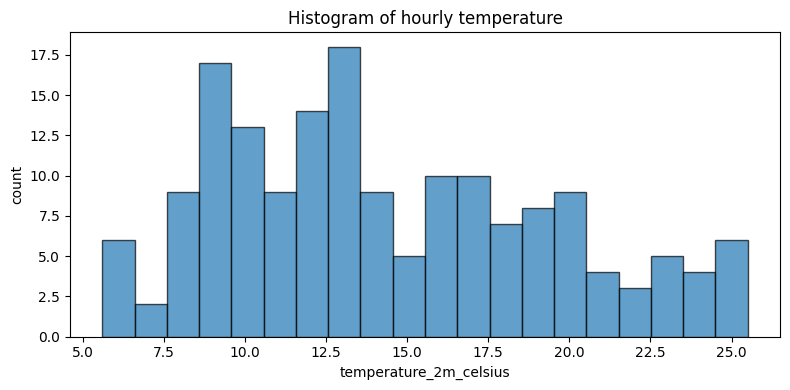

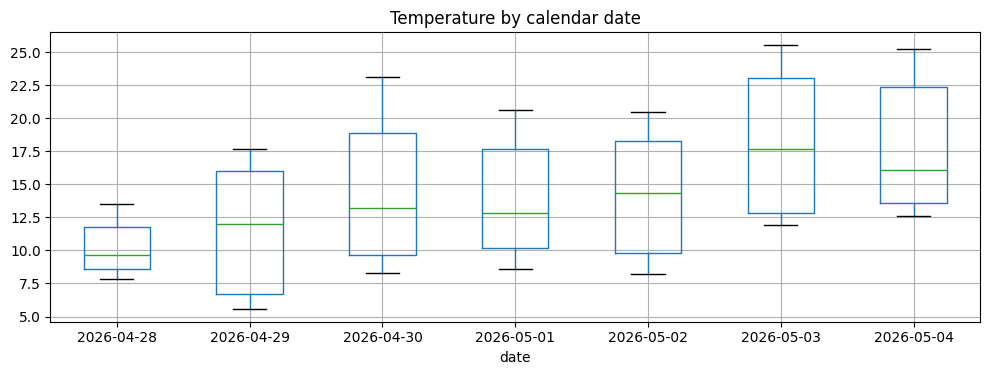


Summary stats by calendar date:


,count,mean,std,min,25%,50%,75%,max
calendar_date,,,,,,,,
2026-04-28,24.0,10.120833,1.889094,7.8,8.575,9.65,11.800,13.5
2026-04-29,24.0,11.679167,4.487081,5.6,6.725,12.00,16.000,17.7
2026-04-30,24.0,14.429167,5.138726,8.3,9.650,13.20,18.900,23.1
2026-05-01,24.0,14.012500,4.166775,8.6,10.175,12.80,17.650,20.6
2026-05-02,24.0,14.291667,4.434540,8.2,9.775,14.35,18.300,20.5
2026-05-03,24.0,18.125000,5.064218,11.9,12.825,17.70,23.025,25.5
2026-05-04,24.0,17.775000,4.742431,12.6,13.550,16.10,22.325,25.2


In [6]:
# 2 — distribution of temperature_2m_celsius
col = "temperature_2m_celsius"

print("Summary statistics (full series):")
display(df[col].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[col], bins=20, edgecolor="black", alpha=0.7)
ax.set_xlabel("temperature_2m_celsius")
ax.set_ylabel("count")
ax.set_title("Histogram of hourly temperature")
plt.tight_layout()
plt.show()

# Compare across calendar days
df["calendar_date"] = df["time"].dt.date

fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot(column=col, by="calendar_date", ax=ax)
plt.suptitle("")  # remove pandas default subtitle
ax.set_title("Temperature by calendar date")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

print("\nSummary stats by calendar date:")
display(df.groupby("calendar_date")[col].describe())

In [7]:
# 3 — subset: daytime hours 08–17 (local clock on the timestamp)
hours = df["time"].dt.hour
subset = df.loc[hours.between(8, 17)].copy()

print("Full dataset rows:", len(df))
print("Subset rows (08:00–17:00):", len(subset))

compare = pd.DataFrame({
    "full_temp": df["temperature_2m_celsius"].describe(),
    "subset_temp": subset["temperature_2m_celsius"].describe(),
    "full_wind": df["wind_speed_10m_kmh"].describe(),
    "subset_wind": subset["wind_speed_10m_kmh"].describe(),
})
display(compare)

Full dataset rows: 168
Subset rows (08:00–17:00): 70


,full_temp,subset_temp,full_wind,subset_wind
count,168.000000,70.000000,168.000000,70.000000
mean,14.347619,17.745714,9.188690,11.151429
std,5.096822,4.767088,4.218202,3.951142
min,5.600000,8.800000,1.800000,2.100000
25%,10.100000,13.550000,6.200000,9.200000
50%,13.300000,17.900000,8.500000,12.050000
75%,17.850000,21.125000,12.325000,14.400000
max,25.500000,25.500000,20.300000,16.700000


In [8]:
one_day = df.loc[df["time"].dt.date == pd.Timestamp("2026-05-04").date()].copy()
print("Rows on that day:", len(one_day))
display(pd.DataFrame({
    "full_temp": df["temperature_2m_celsius"].describe(),
    "day_temp": one_day["temperature_2m_celsius"].describe(),
    "full_wind": df["wind_speed_10m_kmh"].describe(),
    "day_wind": one_day["wind_speed_10m_kmh"].describe(),
}))

Rows on that day: 24


,full_temp,day_temp,full_wind,day_wind
count,168.000000,24.000000,168.000000,24.000000
mean,14.347619,17.775000,9.188690,12.391667
std,5.096822,4.742431,4.218202,6.123576
min,5.600000,12.600000,1.800000,1.800000
25%,10.100000,13.550000,6.200000,7.350000
50%,13.300000,16.100000,8.500000,15.200000
75%,17.850000,22.325000,12.325000,16.175000
max,25.500000,25.200000,20.300000,20.300000


In [9]:
# 5 — missingness and precipitation distinct values
print("Missing values per column:")
display(df.isna().sum())

# Rows where any column is NA
any_missing = df.isna().any(axis=1)
print("\nRows with at least one NA:", int(any_missing.sum()))

# Optional: non-null but empty string (usually none after read_csv)
for c in df.columns:
    if df[c].dtype == object:
        blank = (df[c].astype(str).str.strip() == "").sum()
        if blank:
            print(f"Empty-string-like cells in {c}:", int(blank))

precip = df["precipitation_mm"]
print("\nprecipitation_mm — number of distinct values:", precip.nunique(dropna=False))
print("Value counts (top):")
display(precip.value_counts())

if precip.nunique(dropna=False) <= 1:
    print(
        "\nInterpretation: precipitation_mm has no useful spread for variance/correlation;"
        " it is effectively constant in this file."
    )

Missing values per column:


time                            0
temperature_2m_celsius          0
relative_humidity_2m_percent    0
precipitation_mm                0
wind_speed_10m_kmh              0
calendar_date                   0
dtype: int64


Rows with at least one NA: 0

precipitation_mm — number of distinct values: 1
Value counts (top):


precipitation_mm
0.0    168
Name: count, dtype: int64


Interpretation: precipitation_mm has no useful spread for variance/correlation; it is effectively constant in this file.
